# Impact Analysis with Life-like network automata

This Notebook refers to the manuscript `impact_analysis.tex`

In [ ]:
import gc # import garbage collector

from matplotlib import pyplot as plt

import seaborn as sns
import pandas as pd

import numpy as np
import cellpylib as cpl
import igraph as ig
import h5py

import torch as tc

from matplotlib import rcParams

from tqdm import tqdm

# Configure matplotlib backend for stability
import matplotlib

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "figure.dpi": 100,
    "savefig.dpi": 300,
})

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *

from src.analysis import hamming_weight, boolean_sens, mean_field_dens_propagation, derrida_map_analytical
from src.rules import return_life_like_dict, return_equivalent_rule, binary_indices
from src.networks import create_2d_torus_lattice, watts_strogatz_rewire
from src.visual import get_ugent_colors_dict

life_like_dict = return_life_like_dict()

figures_dir = './figures/impact_analysis/'

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Introduction

- Background and rationale of the work
- Existing approaches
- Our research question

## Definitions

### Definition of the small world network

In [71]:
# various networks have different distributions of centrality measures on their nodes

# Create a small-world network using the Watts-Strogatz model

# Parameters
width = 30                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast. 200 takes 10 minutes
num_nodes = width**2
rewiring_prob = 0.2         # Rewiring probability
p_string = f"{rewiring_prob:.2f}".replace('.', 'p')
degree = 8
num_edges = num_nodes*degree//2

# Create toroidal lattice and rewire.
lattice_graph = create_2d_torus_lattice(width, degree=degree)
small_world_graph = watts_strogatz_rewire(lattice_graph, rewiring_prob)

small_world_graph.to_directed()
small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
small_world_graph.to_undirected()

In [72]:
def node_h_indices(g):
    """Calculate h-index for each node in the graph."""
    h_indices = []
    
    for node in range(g.vcount()):
        # Get neighbors of this node
        neighbors = g.neighbors(node)
        
        # Get degrees of neighbors
        neighbor_degrees = [g.degree(n) for n in neighbors]
        
        # Sort in descending order
        neighbor_degrees_sorted = sorted(neighbor_degrees, reverse=True)
        
        # Calculate h-index for this node
        h = 0
        for i, degree in enumerate(neighbor_degrees_sorted, 1):
            if degree >= i:
                h = i
            else:
                break
        
        h_indices.append(h)
    
    return h_indices

In [73]:
# Get basic network properties
print(f"Network: {small_world_graph.vcount()} nodes, {small_world_graph.ecount()} edges")

# Compute degree distribution instead (much faster and safer)
degrees = small_world_graph.degree()
avg_neigh_degree = small_world_graph.knn()[0]
h_index = node_h_indices(small_world_graph)
eigenvector = small_world_graph.eigenvector_centrality()
betweenness = small_world_graph.betweenness()
closeness = small_world_graph.closeness()

Network: 900 nodes, 3600 edges


Plot created successfully
Garbage collected: 22244 objects


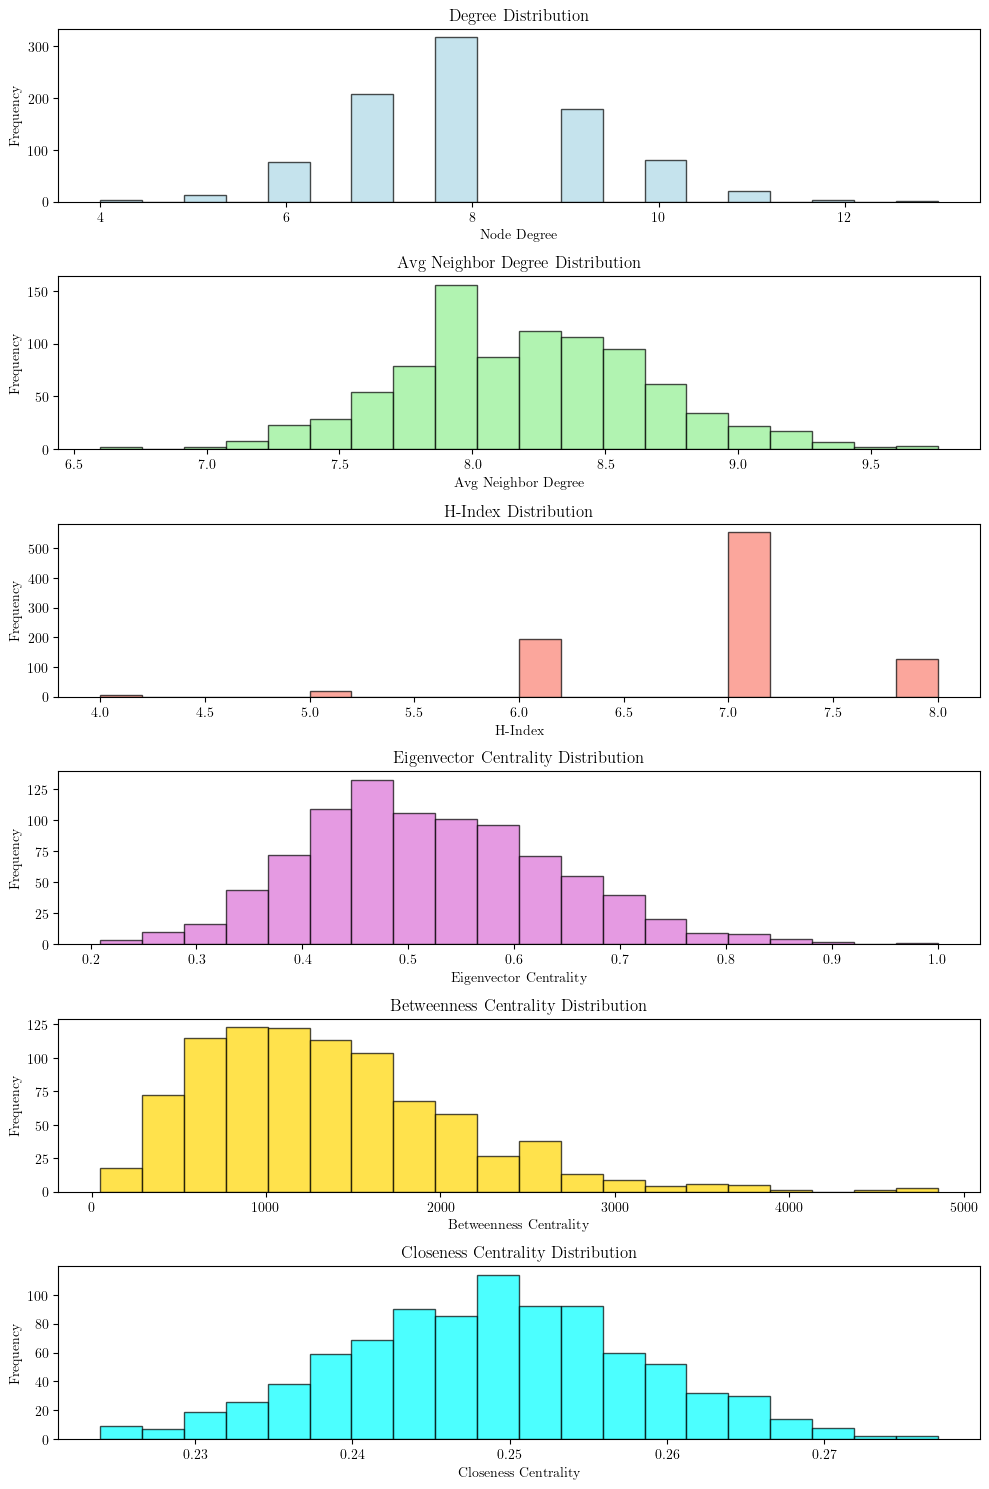

In [74]:
# Create a simple plot
fig, axs = plt.subplots(6, 1, figsize=(10, 15))

# degree
axs[0].hist(degrees, bins=20, color='lightblue', edgecolor='black', alpha=0.7)
axs[0].set_xlabel('Node Degree')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Degree Distribution')

# avg neighbor degree
axs[1].hist(avg_neigh_degree, bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axs[1].set_xlabel('Avg Neighbor Degree')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Avg Neighbor Degree Distribution')

# do the same for h-index
axs[2].hist(h_index, bins=20, color='salmon', edgecolor='black', alpha=0.7)
axs[2].set_xlabel('H-Index')
axs[2].set_ylabel('Frequency')
axs[2].set_title('H-Index Distribution')

# do the same for eigenvector centrality
axs[3].hist(eigenvector, bins=20, color='orchid', edgecolor='black', alpha=0.7)
axs[3].set_xlabel('Eigenvector Centrality')
axs[3].set_ylabel('Frequency')
axs[3].set_title('Eigenvector Centrality Distribution')

# repeat for betweenness
axs[4].hist(betweenness, bins=20, color='gold', edgecolor='black', alpha=0.7)
axs[4].set_xlabel('Betweenness Centrality')
axs[4].set_ylabel('Frequency')
axs[4].set_title('Betweenness Centrality Distribution')

# and for closeness
axs[5].hist(closeness, bins=20, color='cyan', edgecolor='black', alpha=0.7)
axs[5].set_xlabel('Closeness Centrality')
axs[5].set_ylabel('Frequency')
axs[5].set_title('Closeness Centrality Distribution')

# axs[2].hist(h_index, bins=20, color='salmon', edgecolor='black', alpha=0.7)
plt.tight_layout()

print("Plot created successfully")

collected = gc.collect()
print(f"Garbage collected: {collected} objects")

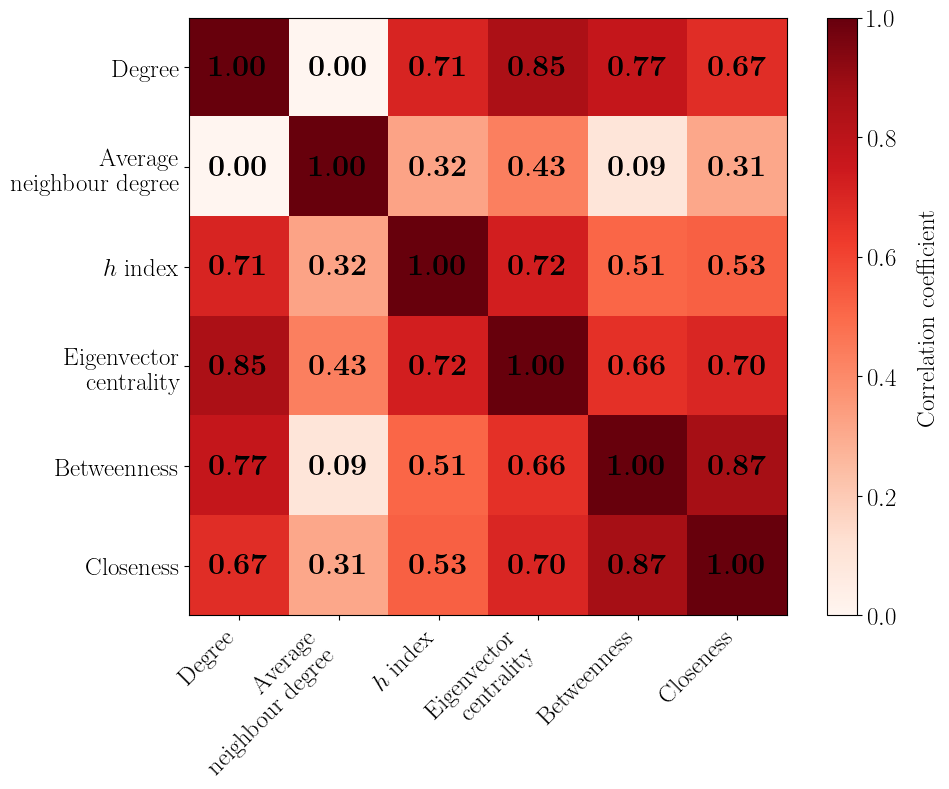

In [75]:
# Combine all metrics into a single array
metrics = np.column_stack([degrees, avg_neigh_degree, h_index, eigenvector, betweenness, closeness])
metric_names = ['Degree', 'Average\nneighbour degree', r'$h$ index', 'Eigenvector\ncentrality', 'Betweenness', 'Closeness']

# Calculate correlation matrix
corr_matrix = np.corrcoef(metrics.T)

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
fontsize = 18

cmap = 'Reds'
im = ax.imshow(corr_matrix, cmap=cmap, vmin=0, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(metric_names)))
ax.set_yticks(np.arange(len(metric_names)))
ax.set_xticklabels(metric_names, rotation=45, ha='right')
ax.set_yticklabels(metric_names)

# increase fontsize of tick labels
ax.tick_params(axis='both', which='major', labelsize=fontsize)

# increase tick label size of colorbar
cbar = plt.colorbar(im, ax=ax, label='Correlation coefficient')
cbar.ax.tick_params(labelsize=fontsize)
cbar.ax.yaxis.label.set_fontsize(fontsize)
# move label to the right a bit
# cbar.ax.yaxis.set_label_position('right')
cbar.ax.yaxis.labelpad = 15

# Add correlation values to cells
for i in range(len(metric_names)):
    for j in range(len(metric_names)):
        text = ax.text(j, i, r'$\mathbf{' + f'{corr_matrix[i, j]:.2f}' + r'}$',
                      ha="center", va="center", color="black", fontsize=fontsize+4)

# plt.title('Correlation Matrix of Network Centrality Measures')
plt.tight_layout()
plt.savefig(figures_dir+f'correlation_matrix_centrality_measures_width{width}_degree{degree}_p{p_string}.pdf')
plt.show()

_ = gc.collect()

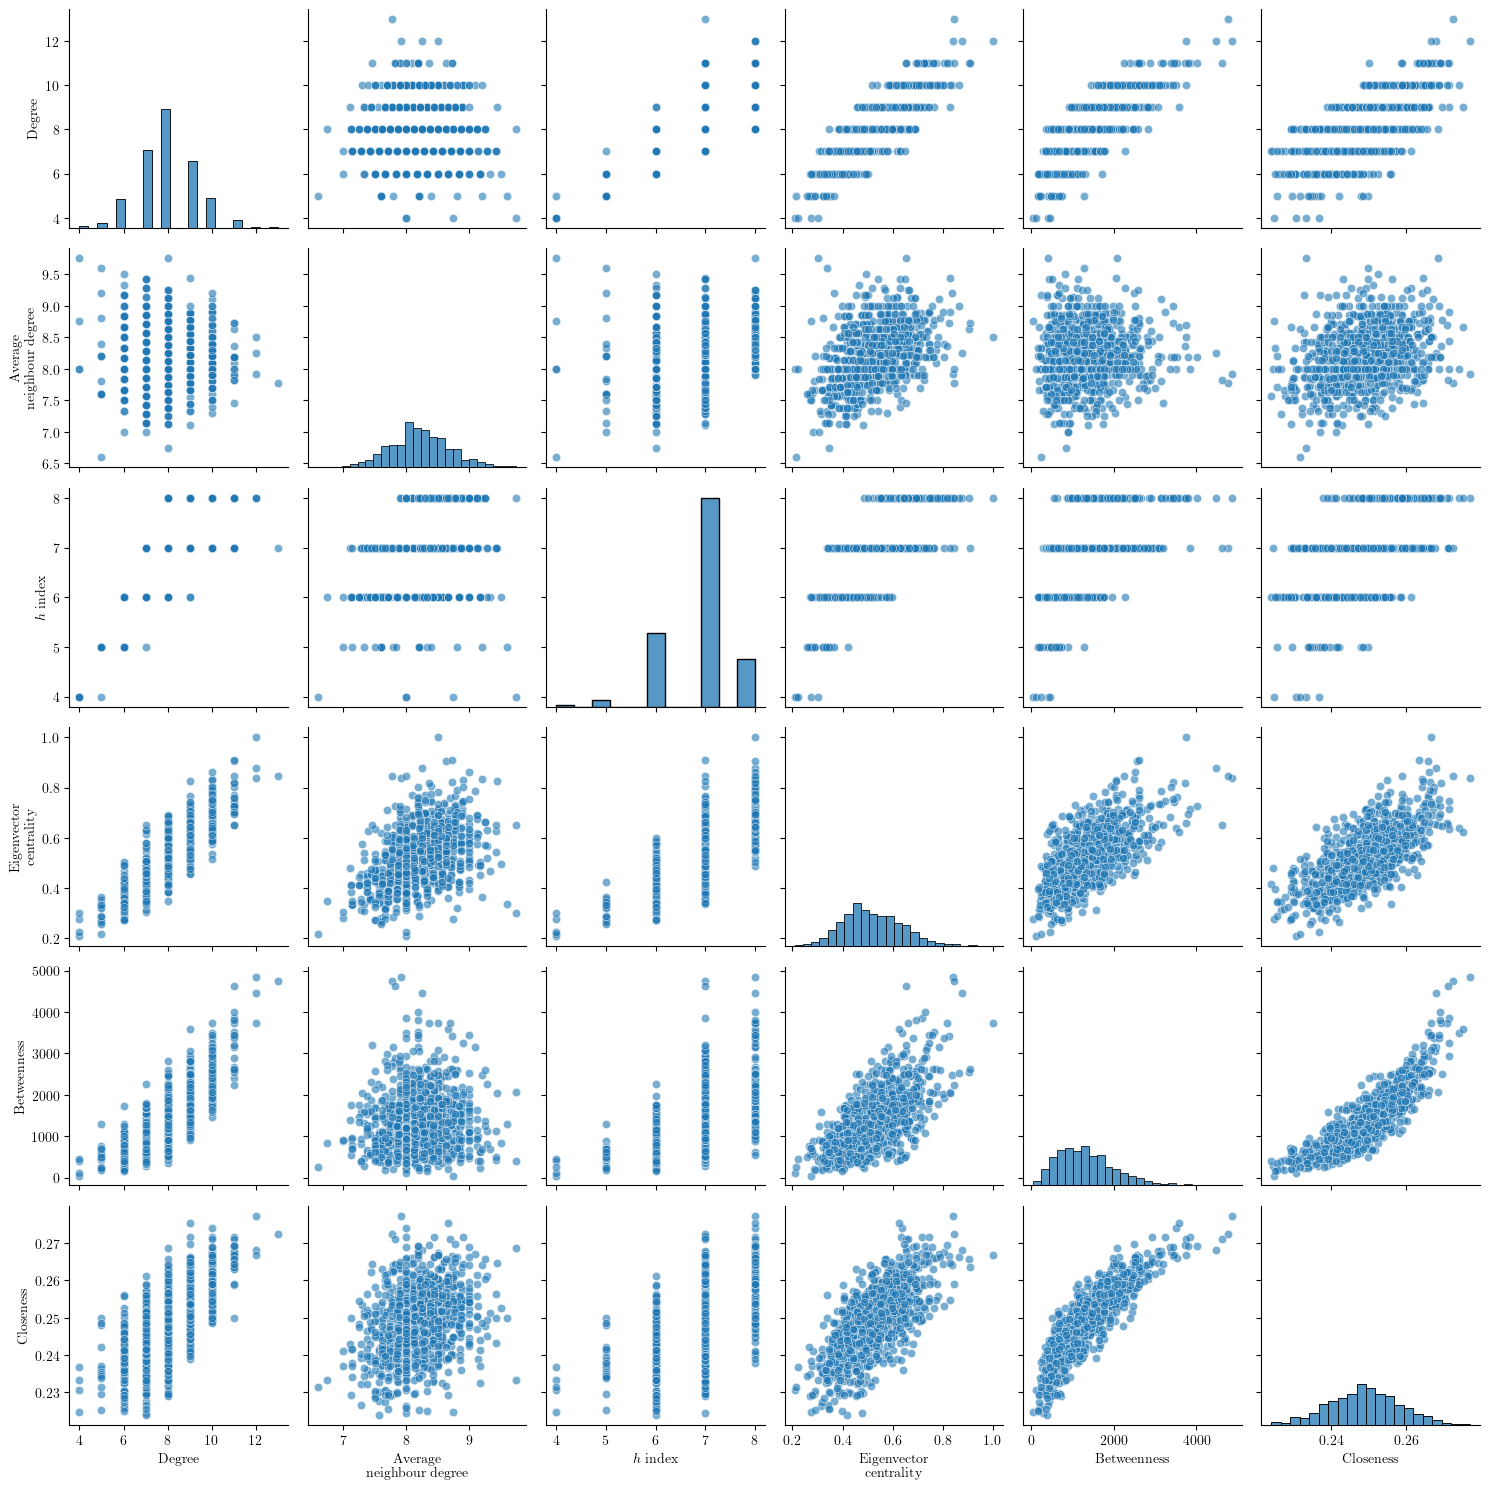

In [76]:
# Create dataframe
df = pd.DataFrame(metrics, columns=metric_names)

# Create pairplot
sns.pairplot(df, diag_kind='hist', plot_kws={'alpha': 0.6})
plt.tight_layout()
plt.show()

### Definition of the LLNA

### Definition of HW and BS

## Methods

### Structural ranking

### Node pinning